# 05_统计检验方法-方差齐性检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这个小节来聊聊方差齐性检验\~

**第一，什么是方差齐性？**

方差就是数据的“离散程度”，也就是数据离平均值的远近程度。

方差齐性（homogeneity of variance）就是说**不同组的数据波动大小差不多**。

举例：你测量两个班的数学成绩，班A成绩波动很大（有很高也有很低），班B成绩波动很小（大家成绩差不多），那这两个班的方差就不齐。

**第二，为什么要检验方差齐性？**

很多统计方法（如 t 检验、方差分析 ANOVA）都有一个假设：各组的方差差不多，如果这个假设不成立，结论可能不可靠。

所以先检查方差是否齐性是一个**前置步骤**。

**第三，一个小例子**：

你想比较两种教学方法对考试成绩的影响。

如果两组学生的成绩波动差不多（方差齐），你可以直接用 t 检验。

如果波动差别很大（方差不齐），就需要调整方法，比如用 Welch t 检验或非参数方法。

## 核心原理

### 1. **F检验（双样本方差比检验）**

假设我们有两组样本 $X_1, X_2, \dots, X_{n_1}$ 和 $Y_1, Y_2, \dots, Y_{n_2}$，方差分别为 $\sigma_1^2$ 和 $\sigma_2^2$。

**步骤：**

1. 计算两组样本方差：


$$
s_1^2 = \frac{1}{n_1-1}\sum_{i=1}^{n_1} (X_i - \bar{X})^2, \quad s_2^2 = \frac{1}{n_2-1}\sum_{i=1}^{n_2} (Y_i - \bar{Y})^2
$$


1. 构造检验统计量：


$$
F = \frac{s_1^2}{s_2^2}, \quad \text{（通常让大方差在分子）}
$$


1. **理论依据：**

   - 如果两组数据都是正态分布，并且方差相等 $(\sigma_1^2 = \sigma_2^2)$，则统计量 $F$ 服从自由度为 $(n_1-1, n_2-1)$ 的 F 分布。
2. 检验：

   - 零假设 $H_0$：$\sigma_1^2 = \sigma_2^2$
   - 备择假设 $H_1$：$\sigma_1^2 \neq \sigma_2^2$
   - 根据 F 分布查表或计算 P 值判断是否拒绝 $H_0$。

**特点：**

- 对正态分布要求高，如果数据偏离正态，可能不适用。

### 2. **Bartlett检验（多样本方差齐性）**

适合多组样本：

假设有 $k$ 组样本，每组样本量为 $n_i$，样本方差为 $s_i^2$。

**公式推导：**

1. 总自由度：


$$
N = \sum_{i=1}^{k} n_i
$$


1. 总样本加权方差：


$$
s_p^2 = \frac{ \sum_{i=1}^{k} (n_i - 1) s_i^2 }{ \sum_{i=1}^{k} (n_i - 1) }
$$


1. 构造统计量：


$$
\chi^2 = \frac{ (N - k) \ln(s_p^2) - \sum_{i=1}^{k} (n_i - 1) \ln(s_i^2) }{ 1 + \frac{1}{3(k-1)}\left( \sum_{i=1}^{k} \frac{1}{n_i - 1} - \frac{1}{N-k} \right) }
$$


1. 理论依据：

   - 当各组数据为正态分布时，统计量 $\chi^2$ 近似服从自由度为 $k-1$ 的卡方分布。
2. 检验：

   - 零假设 $H_0$：各组方差相等
   - 备择假设 $H_1$：至少一组方差不等

---

### 3. **Levene检验（更稳健的方法）**

**思想：**

- 不严格要求正态分布，比较各组的“偏离中位数”的绝对值。

**步骤：**

1. 对每个样本计算与组均值或组中位数的绝对偏差：


$$
Z_{ij} = | X_{ij} - \bar{X}_i | \quad \text{或} \quad Z_{ij} = | X_{ij} - \text{median}_i |
$$


1. 对偏差做单因素方差分析：


$$
F = \frac{ \sum_{i=1}^{k} n_i (\bar{Z}_i - \bar{Z})^2 / (k-1) }{ \sum_{i=1}^{k} \sum_{j=1}^{n_i} (Z_{ij} - \bar{Z}_i)^2 / (N-k) }
$$


1. 零假设 $H_0$：各组方差相等

   - F 统计量服从自由度为 $(k-1, N-k)$ 的 F 分布

**优点：**

- 对非正态分布更稳健，比 Bartlett 检验更可靠。

## 方差齐性检验的算法流程

1. **准备数据**

   - 收集不同组样本数据，计算每组样本量 $n_i$ 和样本方差 $s_i^2$。
2. **选择检验方法**

   - 两组且数据接近正态：F 检验
   - 多组且数据接近正态：Bartlett 检验
   - 多组或不确定正态性：Levene 检验
3. **计算统计量**

   - F 检验：$F = s_1^2 / s_2^2$
   - Bartlett 检验：计算 $\chi^2$ 统计量
   - Levene 检验：计算基于偏差的 F 统计量
4. **确定自由度**

   - F 检验：$(n_1-1, n_2-1)$
   - Bartlett：$k-1$
   - Levene：$(k-1, N-k)$
5. **查表或计算 P 值**

   - 根据统计量和自由度，求出 P 值
6. **作出判断**

   - P 值 < 显著性水平 $\alpha$ → 拒绝 $H_0$ → 方差不齐
   - P 值 ≥ $\alpha$ → 不拒绝 $H_0$ → 方差齐性可以成立

## 完整案例

我们假设有一个教育研究实验，研究三种不同的教学方法（A、B、C）对学生成绩的影响。

每种教学方法有 30 个学生成绩数据。

为了让例子具有实际意义，我们让三组成绩的方差不同：

- 方法 A：成绩波动小（标准差 5）
- 方法 B：成绩波动中等（标准差 8）
- 方法 C：成绩波动大（标准差 12）

目的是通过**方差齐性检验**判断三组成绩的方差是否接近，从而决定后续是否可以直接使用 ANOVA 检验。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/2939319988.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Score', data=df, palette='Set2')


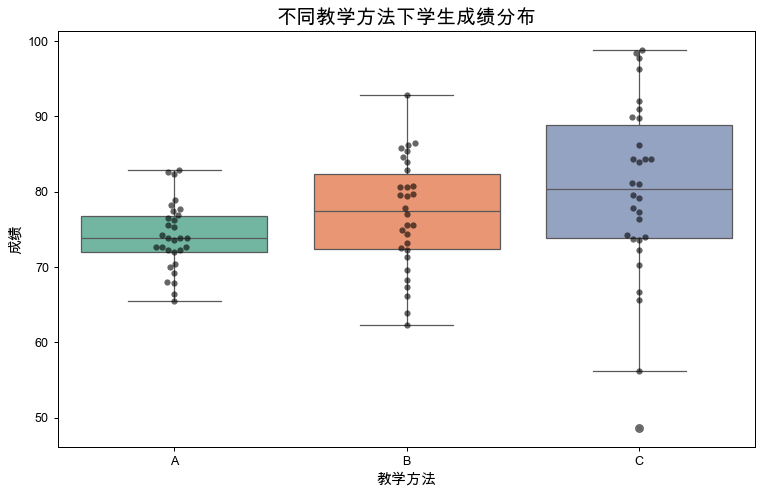

Bartlett检验统计量: 24.9028, P值: 0.0000
Levene检验统计量: 8.9174, P值: 0.0003

各组成绩描述统计:
            mean        std         var
Group                                  
A      74.059266   4.500032   20.250289
B      77.030700   7.448818   55.484883
C      80.154617  11.903796  141.700371


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/2939319988.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/2939319988.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')


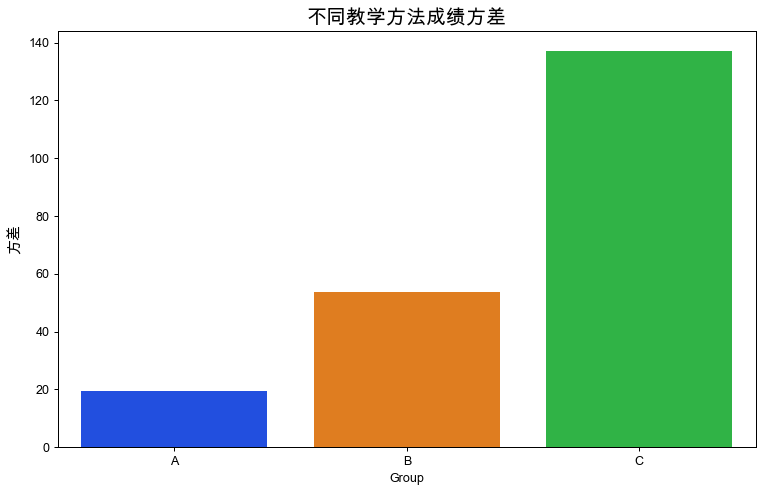

Bartlett检验结果: 拒绝零假设，方差不齐
Levene检验结果: 拒绝零假设，方差不齐


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 数据生成
# 假设我们有三个不同教学方法对学生考试成绩的影响
np.random.seed(42)  # 保持随机性一致性

# 方法A: 成绩波动较小
group_A = np.random.normal(loc=75, scale=5, size=30)
# 方法B: 成绩波动中等
group_B = np.random.normal(loc=78, scale=8, size=30)
# 方法C: 成绩波动较大
group_C = np.random.normal(loc=80, scale=12, size=30)

# 整合数据
scores = np.concatenate([group_A, group_B, group_C])
groups = ['A']*30 + ['B']*30 + ['C']*30

df = pd.DataFrame({'Group': groups, 'Score': scores})

# 2. 数据可视化
plt.figure(figsize=(10,6))
sns.boxplot(x='Group', y='Score', data=df, palette='Set2')
sns.swarmplot(x='Group', y='Score', data=df, color='k', alpha=0.6)
plt.title('不同教学方法下学生成绩分布', fontsize=16)
plt.ylabel('成绩', fontsize=12)
plt.xlabel('教学方法', fontsize=12)
plt.show()

# 3. 方差齐性检验
# 3.1 Bartlett检验
bartlett_stat, bartlett_p = stats.bartlett(group_A, group_B, group_C)
print(f"Bartlett检验统计量: {bartlett_stat:.4f}, P值: {bartlett_p:.4f}")

# 3.2 Levene检验 (更稳健, 中位数为基准)
levene_stat, levene_p = stats.levene(group_A, group_B, group_C, center='median')
print(f"Levene检验统计量: {levene_stat:.4f}, P值: {levene_p:.4f}")

# 4. 数据分析
# 计算各组的均值和方差
summary = df.groupby('Group')['Score'].agg(['mean', 'std', 'var'])
print("\n各组成绩描述统计:")
print(summary)

# 可视化方差大小
plt.figure(figsize=(10,6))
sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')
plt.title('不同教学方法成绩方差', fontsize=16)
plt.ylabel('方差', fontsize=12)
plt.show()

# 5. 小结分析
if bartlett_p < 0.05:
    print("Bartlett检验结果: 拒绝零假设，方差不齐")
else:
    print("Bartlett检验结果: 不拒绝零假设，方差齐")

if levene_p < 0.05:
    print("Levene检验结果: 拒绝零假设，方差不齐")
else:
    print("Levene检验结果: 不拒绝零假设，方差齐")

### 1. 数据生成

In [3]:
np.random.seed(42)
group_A = np.random.normal(loc=75, scale=5, size=30)
group_B = np.random.normal(loc=78, scale=8, size=30)
group_C = np.random.normal(loc=80, scale=12, size=30)

- `np.random.normal` 用于生成正态分布数据。
- `loc` 是均值，`scale` 是标准差，`size` 是样本量。
- 三组数据均值不同，方差不同，使得检验更具实际意义。
- 设置随机种子保证每次实验结果一致。

### 2. 数据可视化

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/353930273.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Score', data=df, palette='Set2')


<Axes: xlabel='Group', ylabel='Score'>

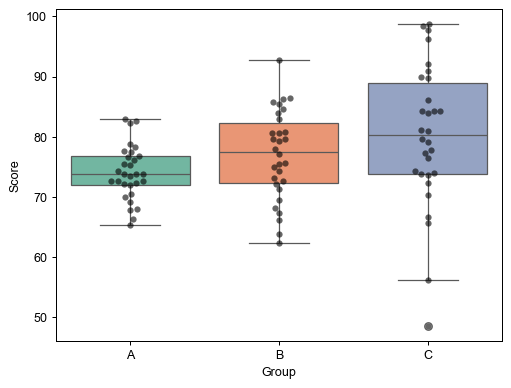

In [4]:
sns.boxplot(x='Group', y='Score', data=df, palette='Set2')
sns.swarmplot(x='Group', y='Score', data=df, color='k', alpha=0.6)

- **箱线图**显示每组数据的分布、中位数、四分位数以及异常值。
- **蜂群图**叠加点分布，更直观看到每个学生成绩。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

目的：初步直观了解各组数据方差和分布情况。

### 3. 方差齐性检验

**3.1 Bartlett 检验**

In [5]:
bartlett_stat, bartlett_p = stats.bartlett(group_A, group_B, group_C)

- 适用于正态分布，灵敏度高。
- 检验零假设 $H_0$：各组方差相等
- 若 P 值 < 0.05，则拒绝 $H_0$，表示方差不齐。

**3.2 Levene 检验**

In [6]:
levene_stat, levene_p = stats.levene(group_A, group_B, group_C, center='median')

- 对非正态数据更稳健。
- 使用中位数作为中心（`center='median'`）可以降低极端值影响。
- 检验零假设同样是各组方差相等。

### 4. 方差和均值描述统计

In [7]:
summary = df.groupby('Group')['Score'].agg(['mean', 'std', 'var'])

- 输出每组均值、标准差和方差。
- 方便和检验结果对照，理解数据实际情况。

### 5. 可视化方差

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/1867615934.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9814/1867615934.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')


<Axes: xlabel='Group', ylabel='Score'>

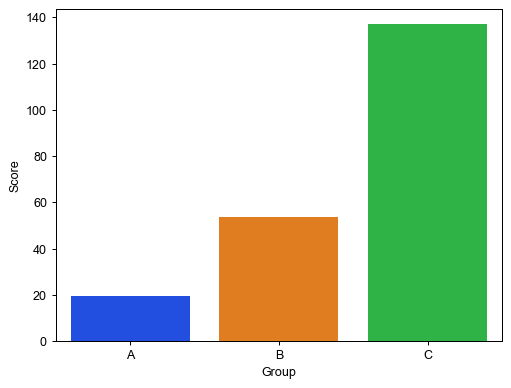

In [8]:
sns.barplot(x='Group', y='Score', data=df, estimator=np.var, ci=None, palette='bright')

- 使用柱状图展示三组的方差大小。
- `estimator=np.var` 指定绘制方差。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 6. 分析结果

根据检验结果：

Bartlett 检验和 Levene 检验都显示 P 值 < 0.05 → 拒绝零假设 → **方差不齐**。

通过柱状图可看到方法 C 的方差明显大于方法 A 和 B。

对应现实意义：方法 C 学生成绩差异更大，教学效果不均衡。

## 方差齐性检验优缺点分析

**优点：**

1. **前置判断作用**：在使用 t 检验或 ANOVA 之前，方差齐性检验可以确保方法假设成立，否则需要调整统计方法。
2. **多方法可选**：

   - F 检验、Bartlett 检验：对正态分布敏感，检验力高。
   - Levene 检验：对非正态稳健。
3. **直观易理解**：通过统计量和 P 值，直接判断是否方差齐。

**缺点：**

1. **对非正态数据敏感**（尤其是 Bartlett 检验），容易出现误判。
2. **样本量影响大**：

   - 小样本时，检验可能无法发现实际差异。
   - 样本量极大时，微小差异也会被检出为显著，可能过于敏感。
3. **只检验方差一致性**：

   - 无法告诉你差异在哪一组，也无法解决差异，只能提示后续处理。

**适用场景：**

- 当你计划使用 **t 检验或 ANOVA**，需要满足方差齐性假设时。
- 数据接近正态分布时，Bartlett 或 F 检验优先。
- 数据可能偏离正态，样本量适中或大时，Levene 检验更稳健。
- 在教育、医学、社会科学实验中，作为分析前置步骤非常必要。

**不适用场景：**

- 数据严重偏态，极端值多时，仅依靠 Bartlett 检验可能误判。
- 样本极小（<10），统计功效低。
- 当研究目标本身不依赖方差齐性时（如非参数检验），则可忽略。

方差齐性检验就是帮我们看看不同组的数据波动大小差不差，先给后续分析打个底。如果检验结果显示方差不齐，就得小心用传统 t 检验或 ANOVA，可能得换稳健方法。

总之，它就像统计分析前的“安全检查”，保证我们算出来的结论靠谱。